Geometry
--------
Dense phase radius = 50.00 um
Dense phase diameter = 100.00 um
Outer radius = 218.40 um
Dense phase volume fraction = 0.0120

Enzyme production rates
-----------------------
Urease rate in dense phase = 4.56 uM/s
Urease rate in dilute phase = 15.74 uM/s
AChE rate in dense phase = 570.34 uM/s
AChE rate in dilute phase = 5.70 uM/s

Water equilibrium from kinetic constants
---------------------------------------
Kw = 1.0673e-02 uM^2
Equivalent Kw = 1.0673e-14 M^2

Initial pH condition
--------------------
Initial pH = 7.080
Initial [H+] = 0.083176 uM = 83.18 nM
Initial [OH-] = 0.128319 uM = 128.32 nM

Solver result
-------------
Success: True
Message: The solver successfully reached the end of the integration interval.

Summary at t = 2400.0 s = 40.0 min


,Region / position,H+ (uM),H+ (nM),pH,OH- (uM),NH3 + NH4+ (uM),Carbonic species (uM),Acetic species (uM)
0,Dense center,0.033674,33.673924,7.472706,0.317156,74804.054486,37435.738897,30348.672226
1,"Dense surface, inside",0.016481,16.481040,7.783015,0.673348,74838.624564,37438.761091,30174.702439
2,Just outside dense phase,0.013610,13.609603,7.866155,0.803598,74841.165084,37439.021502,30159.136551
3,Outer dilute boundary,0.003533,3.533305,8.451819,3.020685,74890.792889,37443.143692,29925.875897
4,Dense volume average,0.024918,24.918104,7.603485,0.456627,74826.326999,37437.633855,30240.396437
5,Dilute volume average,0.003667,3.667206,8.435665,2.953624,74886.159267,37442.782423,29945.950683
6,Global volume average,0.003922,3.922216,8.406468,2.923660,74885.441280,37442.720640,29949.484032


,time_s,time_min,pH_dense_avg,pH_dilute_avg,pH_global_avg,pH_center,pH_outer,H_dense_avg_nM,H_dilute_avg_nM,H_global_avg_nM,delta_pH_dense_minus_dilute
256,2340.125786,39.002096,7.597786,8.437622,8.407837,7.466936,8.454012,25.247222,3.650716,3.909874,-0.839836
257,2355.094340,39.251572,7.599223,8.437128,8.407492,7.468389,8.453458,25.163845,3.654874,3.912981,-0.837905
258,2370.062893,39.501048,7.600652,8.436637,8.407149,7.469835,8.452908,25.081207,3.659008,3.916074,-0.835985
259,2385.031447,39.750524,7.602072,8.436149,8.406808,7.471274,8.452361,24.999297,3.663118,3.919153,-0.834077
260,2400.000000,40.000000,7.603485,8.435665,8.406468,7.472706,8.451819,24.918104,3.667206,3.922216,-0.832180


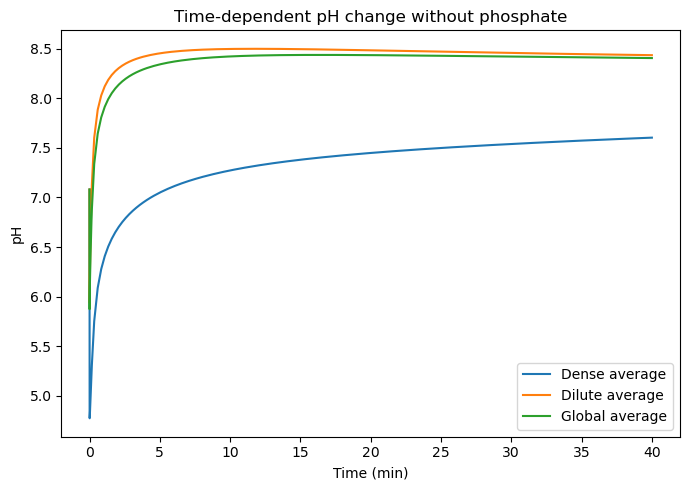

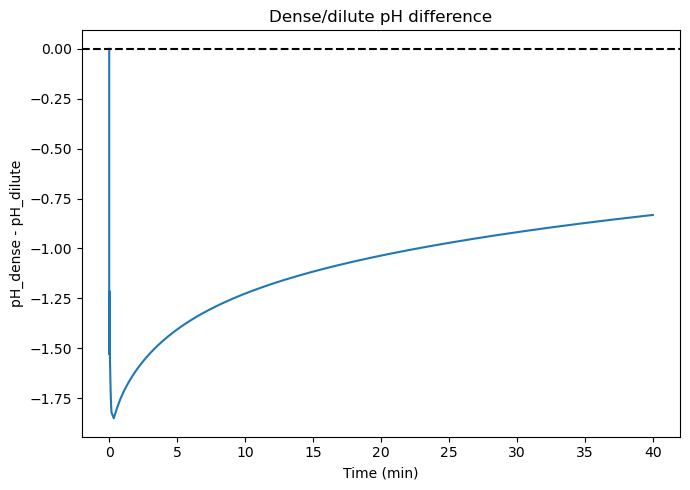

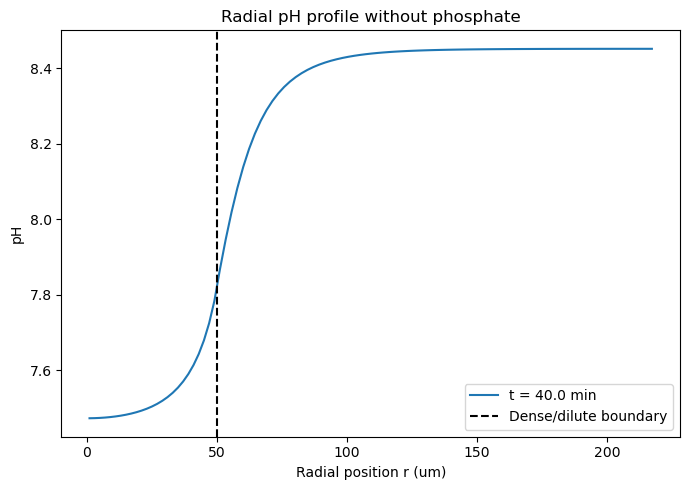

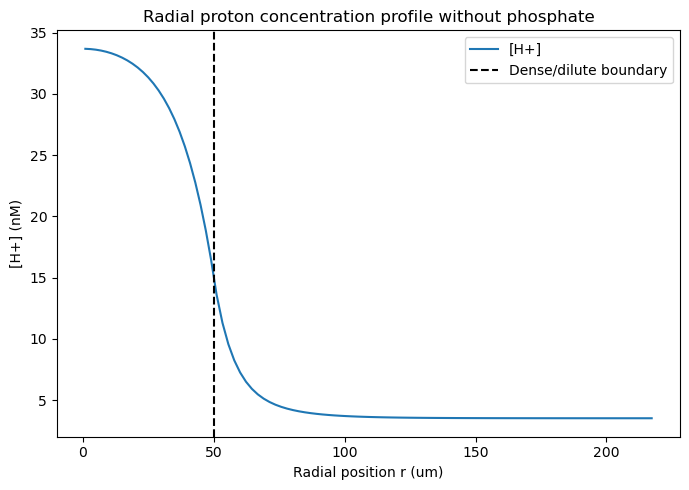

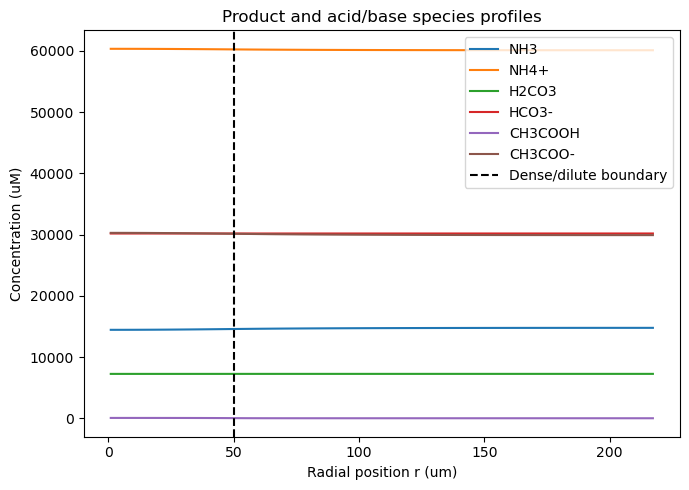

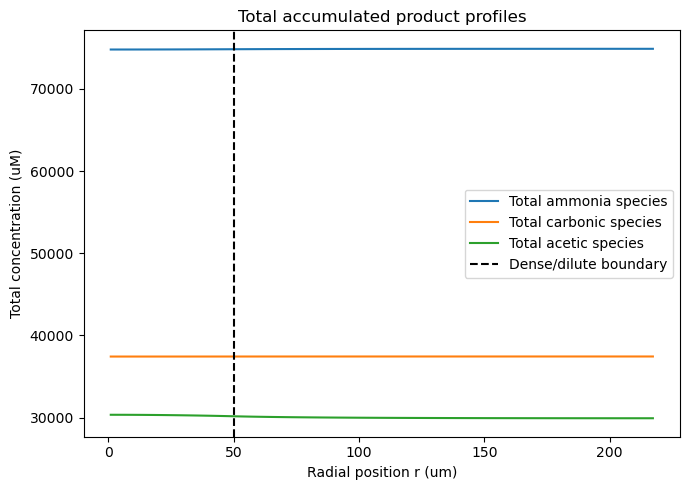


Saved files:
1. proton_RD_no_phosphate_final_profile.csv
2. proton_RD_no_phosphate_timecourse.csv
3. proton_RD_no_phosphate_summary_final.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display

# Droplet Info from ex
phi = 0.012          # dense phase volume fraction
R_dense = 50.0       # dense phase radius, um

# Spherical unit-cell outer radius
R_outer = R_dense / phi**(1/3)

print("Geometry")
print("--------")
print(f"Dense phase radius = {R_dense:.2f} um")
print(f"Dense phase diameter = {2*R_dense:.2f} um")
print(f"Outer radius = {R_outer:.2f} um")
print(f"Dense phase volume fraction = {(R_dense / R_outer)**3:.4f}")

# Numerical grid for spatial resolution; can increase
N_in = 25
N_out = 75

faces_in = np.linspace(0, R_dense, N_in + 1)
faces_out = np.linspace(R_dense, R_outer, N_out + 1)[1:]
faces = np.concatenate([faces_in, faces_out])

r = 0.5 * (faces[:-1] + faces[1:])
N = len(r)

volumes = (4.0 * np.pi / 3.0) * (faces[1:]**3 - faces[:-1]**3)
areas = 4.0 * np.pi * faces**2

inside = r < R_dense
outside = ~inside
mask_all = np.ones_like(inside, dtype=bool)


# Definition of species
species = [
    "H",       # H+
    "OH",      # OH-
    "NH3",     # ammonia
    "NH4",     # ammonium
    "H2CO3",   # carbonic acid
    "HCO3",    # bicarbonate
    "AcOH",    # acetic acid
    "AcO"      # acetate
]

idx = {name: i for i, name in enumerate(species)}
n_species = len(species)

# Definition of diffusion coefficients, um^2/s
D = np.array([
    9310.0,  # H+
    5270.0,  # OH-
    1500.0,  # NH3
    1960.0,  # NH4+
    1670.0,  # H2CO3
    1190.0,  # HCO3-
    1200.0,  # CH3COOH
    1300.0   # CH3COO-
])

# kcat values of enzymes
kcat_urease = 520.0 #520
kcat_AChE = 208.0 #208

# Enzyme concentrations, uM
# TODO: Replace these placeholder values with the measured phase-specific concentrations.
urease_dense = 0.008775
urease_dilute = 0.03026
#urease_dense = 0.020 #Well-mixed condition
#urease_dilute = 0.020 #Well-mixed condition

AChE_dense = 2.742
AChE_dilute = 0.02742
#AChE_dense = 0.050    #Well-mixed condition
#AChE_dilute = 0.050   #Well-mixed condition

urease = np.where(inside, urease_dense, urease_dilute)
AChE = np.where(inside, AChE_dense, AChE_dilute)

# Zero-order enzymatic production rates assuming substrate excess
v_urease = kcat_urease * urease               # uM/s
v_AChE = kcat_AChE * AChE                     # uM/s

print()
print("Enzyme production rates")
print("-----------------------")
print(f"Urease rate in dense phase = {kcat_urease * urease_dense:.2f} uM/s")
print(f"Urease rate in dilute phase = {kcat_urease * urease_dilute:.2f} uM/s")
print(f"AChE rate in dense phase = {kcat_AChE * AChE_dense:.2f} uM/s")
print(f"AChE rate in dilute phase = {kcat_AChE * AChE_dilute:.2f} uM/s")

# Acid-base kinetic constants
# I need to convert the rates to uM^-1 s^-1 from M^-1 s^-1.
M_to_uM_second_order = 1e-6

# NH4+ <-> NH3 + H+
k_deprot_NH4 = 6.9e-4
k_prot_NH3 = 1.2e6 * M_to_uM_second_order

# CO2 <-> HCO3- + H+, pKa 6.35
k_deprot_H2CO3 = 2.2e-3
k_prot_HCO3 = 4.9e3 * M_to_uM_second_order

# CH3COOH <-> CH3COO- + H+
k_deprot_AcOH = 7.8e6
k_prot_AcO = 4.5e11 * M_to_uM_second_order

# H2O <-> H+ + OH-
k_deprot_water = 2.5e-5
k_prot_water = 1.3e11 * M_to_uM_second_order

# Water concentration
H2O_uM = 55.5e6  # 55.5 M

# Constant water deprotonation source
water_deprot_source = k_deprot_water * H2O_uM  # uM/s

# Kinetic Kw in uM^2
Kw_uM2 = water_deprot_source / k_prot_water

print()
print("Water equilibrium from kinetic constants")
print("---------------------------------------")
print(f"Kw = {Kw_uM2:.4e} uM^2")
print(f"Equivalent Kw = {Kw_uM2 * 1e-12:.4e} M^2")

# Initial conditions
# pH_initial = 7.1 or 8.1
pH_initial = 7.08

# H+ in uM
H_initial = 10**(-pH_initial) * 1e6

# OH- from water kinetic equilibrium
OH_initial = Kw_uM2 / H_initial

print()
print("Initial pH condition")
print("--------------------")
print(f"Initial pH = {pH_initial:.3f}")
print(f"Initial [H+] = {H_initial:.6f} uM = {H_initial*1000:.2f} nM")
print(f"Initial [OH-] = {OH_initial:.6f} uM = {OH_initial*1000:.2f} nM")

# Initial concentration matrix: species x radial shells
Y0 = np.zeros((n_species, N))

Y0[idx["H"], :] = H_initial
Y0[idx["OH"], :] = OH_initial
Y0[idx["NH3"], :] = 0.0
Y0[idx["NH4"], :] = 0.0
Y0[idx["H2CO3"], :] = 0.0
Y0[idx["HCO3"], :] = 0.0
Y0[idx["AcOH"], :] = 0.0
Y0[idx["AcO"], :] = 0.0

# Diffusion operator
def diffusion_terms(C):
    """
    Calculate finite-volume diffusion terms for all species.

    C shape: n_species x N
    Returns dC/dt from diffusion only, same shape.
    """

    dCdt_diff = np.zeros_like(C)

    for s in range(n_species):
        Cs = C[s, :]

        flux = np.zeros(N + 1)

        # Distance between neighboring shell centers
        dr_centers = r[1:] - r[:-1]

        # Fick's law across internal faces
        flux[1:N] = -D[s] * areas[1:N] * (Cs[1:] - Cs[:-1]) / dr_centers

        # No-flux at r = 0 and r = R_outer
        flux[0] = 0.0
        flux[N] = 0.0

        # Diffusive influx into each shell
        dCdt_diff[s, :] = (flux[:-1] - flux[1:]) / volumes

    return dCdt_diff

# Reaction-diffusion right-hand side
def rhs(t, y):
    """
    Time derivative for the full reaction-diffusion system.
    """

    C = y.reshape(n_species, N)

    # Prevent tiny negative values from causing unstable reaction rates. This is only for rate evaluation.
    C = np.maximum(C, 0.0)

    H = C[idx["H"], :]
    OH = C[idx["OH"], :]
    NH3 = C[idx["NH3"], :]
    NH4 = C[idx["NH4"], :]
    H2CO3 = C[idx["H2CO3"], :]
    HCO3 = C[idx["HCO3"], :]
    AcOH = C[idx["AcOH"], :]
    AcO = C[idx["AcO"], :]

    dCdt = diffusion_terms(C)

    # Producer and consumer reactions
    # urea -> 2 NH3 + 1 H2CO3
    dCdt[idx["NH3"], :] += 2.0 * v_urease
    dCdt[idx["H2CO3"], :] += 1.0 * v_urease

    # acetylcholine -> acetic acid
    dCdt[idx["AcOH"], :] += v_AChE

    # Acid-base reactions
    # NH4+ <-> NH3 + H+
    r_deprot_NH4 = k_deprot_NH4 * NH4
    r_prot_NH3 = k_prot_NH3 * NH3 * H
    net_NH = r_deprot_NH4 - r_prot_NH3

    dCdt[idx["NH4"], :] += -net_NH
    dCdt[idx["NH3"], :] +=  net_NH
    dCdt[idx["H"], :] +=    net_NH

    # H2CO3 <-> HCO3- + H+
    r_deprot_H2CO3 = k_deprot_H2CO3 * H2CO3
    r_prot_HCO3 = k_prot_HCO3 * HCO3 * H
    net_carbonic = r_deprot_H2CO3 - r_prot_HCO3

    dCdt[idx["H2CO3"], :] += -net_carbonic
    dCdt[idx["HCO3"], :] +=   net_carbonic
    dCdt[idx["H"], :] +=      net_carbonic

    # CH3COOH <-> CH3COO- + H+
    r_deprot_AcOH = k_deprot_AcOH * AcOH
    r_prot_AcO = k_prot_AcO * AcO * H
    net_acetic = r_deprot_AcOH - r_prot_AcO

    dCdt[idx["AcOH"], :] += -net_acetic
    dCdt[idx["AcO"], :] +=   net_acetic
    dCdt[idx["H"], :] +=     net_acetic

    # H2O <-> H+ + OH-
    r_deprot_water = water_deprot_source
    r_prot_water = k_prot_water * H * OH
    net_water = r_deprot_water - r_prot_water

    dCdt[idx["H"], :] += net_water
    dCdt[idx["OH"], :] += net_water

    return dCdt.ravel()

# Helper functions
def volume_average(x, mask):
    return np.sum(x[mask] * volumes[mask]) / np.sum(volumes[mask])

def pH_from_H_uM(H_uM):
    H_uM_safe = np.maximum(H_uM, 1e-30)
    return -np.log10(H_uM_safe * 1e-6)

def summarize_solution(sol, time_index=-1):
    C = sol.y[:, time_index].reshape(n_species, N)

    H = C[idx["H"], :]
    OH = C[idx["OH"], :]
    NH3 = C[idx["NH3"], :]
    NH4 = C[idx["NH4"], :]
    H2CO3 = C[idx["H2CO3"], :]
    HCO3 = C[idx["HCO3"], :]
    AcOH = C[idx["AcOH"], :]
    AcO = C[idx["AcO"], :]

    summary = pd.DataFrame({
        "Region / position": [
            "Dense center",
            "Dense surface, inside",
            "Just outside dense phase",
            "Outer dilute boundary",
            "Dense volume average",
            "Dilute volume average",
            "Global volume average"
        ],
        "H+ (uM)": [
            H[0],
            H[inside][-1],
            H[outside][0],
            H[-1],
            volume_average(H, inside),
            volume_average(H, outside),
            volume_average(H, mask_all)
        ],
        "H+ (nM)": [
            H[0] * 1000,
            H[inside][-1] * 1000,
            H[outside][0] * 1000,
            H[-1] * 1000,
            volume_average(H, inside) * 1000,
            volume_average(H, outside) * 1000,
            volume_average(H, mask_all) * 1000
        ],
        "pH": [
            pH_from_H_uM(H[0]),
            pH_from_H_uM(H[inside][-1]),
            pH_from_H_uM(H[outside][0]),
            pH_from_H_uM(H[-1]),
            pH_from_H_uM(volume_average(H, inside)),
            pH_from_H_uM(volume_average(H, outside)),
            pH_from_H_uM(volume_average(H, mask_all))
        ],
        "OH- (uM)": [
            OH[0],
            OH[inside][-1],
            OH[outside][0],
            OH[-1],
            volume_average(OH, inside),
            volume_average(OH, outside),
            volume_average(OH, mask_all)
        ],
        "NH3 + NH4+ (uM)": [
            NH3[0] + NH4[0],
            NH3[inside][-1] + NH4[inside][-1],
            NH3[outside][0] + NH4[outside][0],
            NH3[-1] + NH4[-1],
            volume_average(NH3 + NH4, inside),
            volume_average(NH3 + NH4, outside),
            volume_average(NH3 + NH4, mask_all)
        ],
        "Carbonic species (uM)": [
            H2CO3[0] + HCO3[0],
            H2CO3[inside][-1] + HCO3[inside][-1],
            H2CO3[outside][0] + HCO3[outside][0],
            H2CO3[-1] + HCO3[-1],
            volume_average(H2CO3 + HCO3, inside),
            volume_average(H2CO3 + HCO3, outside),
            volume_average(H2CO3 + HCO3, mask_all)
        ],
        "Acetic species (uM)": [
            AcOH[0] + AcO[0],
            AcOH[inside][-1] + AcO[inside][-1],
            AcOH[outside][0] + AcO[outside][0],
            AcOH[-1] + AcO[-1],
            volume_average(AcOH + AcO, inside),
            volume_average(AcOH + AcO, outside),
            volume_average(AcOH + AcO, mask_all)
        ]
    })

    return summary

# Define time, longer time makes very long simulation time so be careful
t_end = 2400.0

# Evaluation times:log-spaced early times + linear later times
t_eval_early = np.logspace(-6, 1, 100)          # 1 us to 10 s
t_eval_late = np.linspace(20, t_end, 160)       # 20 s to 60 min
t_eval = np.unique(np.concatenate(([0.0], t_eval_early, t_eval_late)))

sol = solve_ivp(
    rhs,
    t_span=(0.0, t_end),
    y0=Y0.ravel(),
    method="BDF",
    t_eval=t_eval,
    rtol=1e-5,
    atol=1e-9,
    max_step=1.0
)

print()
print("Solver result")
print("-------------")
print("Success:", sol.success)
print("Message:", sol.message)

# Display final pH summary
print()
print(f"Summary at t = {sol.t[-1]:.1f} s = {sol.t[-1]/60:.1f} min")
summary_final = summarize_solution(sol, time_index=-1)
display(summary_final)

# Time-course of dense and dilute pH
dense_pH = []
dilute_pH = []
global_pH = []
center_pH = []
outer_pH = []

dense_H_nM = []
dilute_H_nM = []
global_H_nM = []

for j in range(len(sol.t)):
    Cj = sol.y[:, j].reshape(n_species, N)
    Hj = Cj[idx["H"], :]

    H_dense_avg = volume_average(Hj, inside)
    H_dilute_avg = volume_average(Hj, outside)
    H_global_avg = volume_average(Hj, mask_all)

    dense_pH.append(pH_from_H_uM(H_dense_avg))
    dilute_pH.append(pH_from_H_uM(H_dilute_avg))
    global_pH.append(pH_from_H_uM(H_global_avg))
    center_pH.append(pH_from_H_uM(Hj[0]))
    outer_pH.append(pH_from_H_uM(Hj[-1]))

    dense_H_nM.append(H_dense_avg * 1000)
    dilute_H_nM.append(H_dilute_avg * 1000)
    global_H_nM.append(H_global_avg * 1000)

dense_pH = np.array(dense_pH)
dilute_pH = np.array(dilute_pH)
global_pH = np.array(global_pH)
center_pH = np.array(center_pH)
outer_pH = np.array(outer_pH)

dense_H_nM = np.array(dense_H_nM)
dilute_H_nM = np.array(dilute_H_nM)
global_H_nM = np.array(global_H_nM)


timecourse = pd.DataFrame({
    "time_s": sol.t,
    "time_min": sol.t / 60,
    "pH_dense_avg": dense_pH,
    "pH_dilute_avg": dilute_pH,
    "pH_global_avg": global_pH,
    "pH_center": center_pH,
    "pH_outer": outer_pH,
    "H_dense_avg_nM": dense_H_nM,
    "H_dilute_avg_nM": dilute_H_nM,
    "H_global_avg_nM": global_H_nM,
    "delta_pH_dense_minus_dilute": dense_pH - dilute_pH
})

display(timecourse.tail())

# Plot pH time-course
plt.figure(figsize=(7, 5))
plt.plot(sol.t / 60, dense_pH, label="Dense average")
plt.plot(sol.t / 60, dilute_pH, label="Dilute average")
plt.plot(sol.t / 60, global_pH, label="Global average")
plt.xlabel("Time (min)")
plt.ylabel("pH")
plt.title("Time-dependent pH change without phosphate")
plt.legend()
plt.tight_layout()
plt.show()

# Plot dense-dilute pH difference
plt.figure(figsize=(7, 5))
plt.plot(sol.t / 60, dense_pH - dilute_pH)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Time (min)")
plt.ylabel("pH_dense - pH_dilute")
plt.title("Dense/dilute pH difference")
plt.tight_layout()
plt.show()

# Final radial pH profile
C_final = sol.y[:, -1].reshape(n_species, N)
H_final = C_final[idx["H"], :]
pH_final = pH_from_H_uM(H_final)

plt.figure(figsize=(7, 5))
plt.plot(r, pH_final, label=f"t = {sol.t[-1]/60:.1f} min")
plt.axvline(R_dense, linestyle="--", color="black", label="Dense/dilute boundary")
plt.xlabel("Radial position r (um)")
plt.ylabel("pH")
plt.title("Radial pH profile without phosphate")
plt.legend()
plt.tight_layout()
plt.show()

# Final H+ profile
plt.figure(figsize=(7, 5))
plt.plot(r, H_final * 1000, label="[H+]")
plt.axvline(R_dense, linestyle="--", color="black", label="Dense/dilute boundary")
plt.xlabel("Radial position r (um)")
plt.ylabel("[H+] (nM)")
plt.title("Radial proton concentration profile without phosphate")
plt.legend()
plt.tight_layout()
plt.show()

# Final acid/base product profiles
plt.figure(figsize=(7, 5))
plt.plot(r, C_final[idx["NH3"], :], label="NH3")
plt.plot(r, C_final[idx["NH4"], :], label="NH4+")
plt.plot(r, C_final[idx["H2CO3"], :], label="H2CO3")
plt.plot(r, C_final[idx["HCO3"], :], label="HCO3-")
plt.plot(r, C_final[idx["AcOH"], :], label="CH3COOH")
plt.plot(r, C_final[idx["AcO"], :], label="CH3COO-")
plt.axvline(R_dense, linestyle="--", color="black", label="Dense/dilute boundary")
plt.xlabel("Radial position r (um)")
plt.ylabel("Concentration (uM)")
plt.title("Product and acid/base species profiles")
plt.legend()
plt.tight_layout()
plt.show()

# Total product profiles
NH_total = C_final[idx["NH3"], :] + C_final[idx["NH4"], :]
carbonic_total = C_final[idx["H2CO3"], :] + C_final[idx["HCO3"], :]
acetic_total = C_final[idx["AcOH"], :] + C_final[idx["AcO"], :]

plt.figure(figsize=(7, 5))
plt.plot(r, NH_total, label="Total ammonia species")
plt.plot(r, carbonic_total, label="Total carbonic species")
plt.plot(r, acetic_total, label="Total acetic species")
plt.axvline(R_dense, linestyle="--", color="black", label="Dense/dilute boundary")
plt.xlabel("Radial position r (um)")
plt.ylabel("Total concentration (uM)")
plt.title("Total accumulated product profiles")
plt.legend()
plt.tight_layout()
plt.show()

# Export results
profile_final = pd.DataFrame({
    "r_um": r,
    "phase": np.where(inside, "dense", "dilute"),
    "H_uM": C_final[idx["H"], :],
    "H_nM": C_final[idx["H"], :] * 1000,
    "pH": pH_final,
    "OH_uM": C_final[idx["OH"], :],
    "NH3_uM": C_final[idx["NH3"], :],
    "NH4_uM": C_final[idx["NH4"], :],
    "NH_total_uM": NH_total,
    "H2CO3_uM": C_final[idx["H2CO3"], :],
    "HCO3_uM": C_final[idx["HCO3"], :],
    "carbonic_total_uM": carbonic_total,
    "AcOH_uM": C_final[idx["AcOH"], :],
    "AcO_uM": C_final[idx["AcO"], :],
    "acetic_total_uM": acetic_total
})

profile_final.to_csv("proton_RD_no_phosphate_final_profile.csv", index=False)
timecourse.to_csv("proton_RD_no_phosphate_timecourse.csv", index=False)
summary_final.to_csv("proton_RD_no_phosphate_summary_final.csv", index=False)

print()
print("Saved files:")
print("1. proton_RD_no_phosphate_final_profile.csv")
print("2. proton_RD_no_phosphate_timecourse.csv")
print("3. proton_RD_no_phosphate_summary_final.csv")